## Import datsets and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

In [2]:
df = pd.read_csv('Student Awareness Survey (Responses) - Form Responses 1.csv')
df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


In [3]:
print("Shape: ",df.shape)

Shape:  (50, 15)


column names

In [4]:
print(df.columns)

Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company that recruits from campus?',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'Your CIA % of last semester', 'Your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='object')


Null values sum

In [5]:
df.isnull().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)

Renaming Columns for Convenience

In [6]:
df.rename(columns={
    'Your CIA % of last semester': 'CIA',
    'Your GPA of last semester': 'GPA',
    'Your maximum attendance % till last semester': 'Attendance'
}, inplace=True)

In [7]:
cols =[
    'CIA',
    'GPA',
    'Attendance'
]

        

data = df[cols].copy()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CIA         50 non-null     object 
 1   GPA         50 non-null     float64
 2   Attendance  50 non-null     object 
dtypes: float64(1), object(2)
memory usage: 1.3+ KB


Removing symbols and whitespaces 

In [8]:
for col in data.columns:
    data[col] = data[col].astype(str).str.replace('%', '', regex = False).str.strip()

data

,CIA,GPA,Attendance
0,69,3.4,98
1,75,3.69,95
2,82,3.41,95
3,91,3.6,92
4,70,3.54,93
5,75,3.67,98
6,74,3.4,94
7,68,3.4,85
8,73,3.6,90
9,79,3.73,93


Converting to numeric

In [9]:
data = data.apply(pd.to_numeric, errors='coerce')

data

,CIA,GPA,Attendance
0,69.00,3.40,98.00
1,75.00,3.69,95.00
2,82.00,3.41,95.00
3,91.00,3.60,92.00
4,70.00,3.54,93.00
5,75.00,3.67,98.00
6,74.00,3.40,94.00
7,68.00,3.40,85.00
8,73.00,3.60,90.00
9,79.00,3.73,93.00


In [10]:
print('Missing values:\n', data.isnull().sum())
data = data.dropna()
print("Shape after dropping NaN:", data.shape)

Missing values:
 CIA           0
GPA           0
Attendance    0
dtype: int64
Shape after dropping NaN: (50, 3)


In [11]:
data.describe()

,CIA,GPA,Attendance
count,50.000000,50.000000,50.000000
mean,71.508600,3.497000,93.824800
std,11.247756,0.690865,3.852926
min,7.000000,2.740000,85.000000
25%,69.195000,3.305000,92.000000
50%,71.445000,3.400000,95.000000
75%,76.750000,3.600000,96.000000
max,91.000000,8.000000,100.000000


### Experiment 1: X = CIA, Y = GPA
### Experiment 2: X = Attendance, Y = GPA

# Simple Linear Regression using Scikit-learn

In [12]:
from IPython.core import application
from IPython.core import application
from sklearn.linear_model import LinearRegression
def sklearn_regression(X,y,feature_name):
    # Performing linear regression using Scikit-learn

    # reshaping X to 2D
    X = X.values.reshape(-1,1)
    y = y.values

    # split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state = 2
    )

    print(f'Training Set Size: {len(X_train)}')
    print(f'Testing Set Size: {len(X_test)}')

    # training the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # getting slope and intercept
    slope = model.coef_[0]
    intercept = model.intercept_
    print(f"\nSlope (m): {slope}")
    print(f"Intercept (b): {intercept}")
    print(f"Equation: GPA = {slope:.4f} * {feature_name} + {intercept:.4f}")

    # predict on test set
    y_pred = model.predict(X_test)

    # visualize
    plt.figure(figsize=(8,5))
    plt.scatter(X_train, y_train, color='blue', label='Training data', alpha=0.6)
    plt.scatter(X_test, y_test, color='green', label='Test data(Actual)', alpha=0.6)
    plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(feature_name)
    plt.ylabel('GPA')
    plt.title(f'Linear Regression: {feature_name} vs GPA (Scikit-learn)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return model, slope, intercept, X_test, y_test, y_pred

## Experiment 1: CIA vs GPA

Training Set Size: 40
Testing Set Size: 10

Slope (m): 0.01244011549410184
Intercept (b): 2.4787899935312168
Equation: GPA = 0.0124 * CIA + 2.4788


Training Set Size: 40
Testing Set Size: 10

Slope (m): 0.01244011549410184
Intercept (b): 2.4787899935312168
Equation: GPA = 0.0124 * CIA + 2.4788


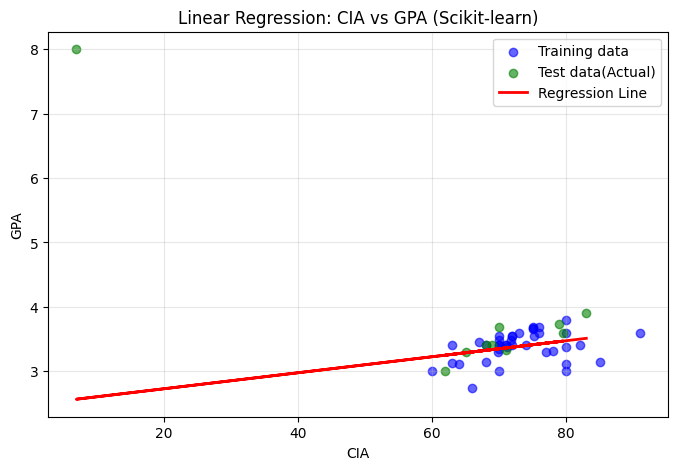

Slope: 0.01244011549410184
Intercept: 2.4787899935312168


In [13]:
X = data["CIA"]
y = data["GPA"]

model1, slope1, intercept1, Xtest1, ytest1, ypred_sk1 = sklearn_regression(X, y, "CIA")

print("Slope:", slope1)
print("Intercept:", intercept1)

In [14]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# Predict the test data
y_pred = model1.predict(Xtest1)

# Calculate evaluation metrics
r2 = r2_score(ytest1, y_pred)
rmse = np.sqrt(mean_squared_error(ytest1, y_pred))
mae = mean_absolute_error(ytest1, y_pred)

# Print the results
print("R² Score :", r2)
print("RMSE     :", rmse)
print("MAE      :", mae)

R² Score : -0.5804993489697676
RMSE     : 1.7308781726135083
MAE      : 0.699596887791859


## Experiment 2: Attendance vs GPA

Training Set Size: 40
Testing Set Size: 10

Slope (m): 0.024169913010882643
Intercept (b): 1.1256553705285919
Equation: GPA = 0.0242 * Attendance + 1.1257


Training Set Size: 40
Testing Set Size: 10

Slope (m): 0.024169913010882643
Intercept (b): 1.1256553705285919
Equation: GPA = 0.0242 * Attendance + 1.1257


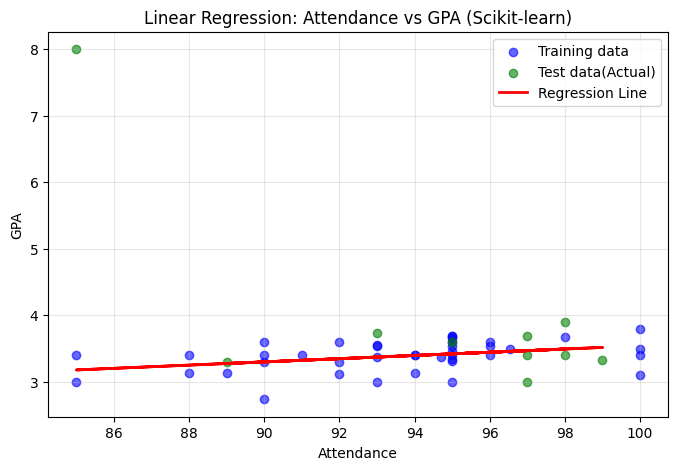

Slope: 0.024169913010882643
Intercept: 1.1256553705285919


In [15]:
X = data["Attendance"]
y = data["GPA"]

model2, slope2, intercept2, Xtest2, ytest2, ypred_sk2 = sklearn_regression(X, y, "Attendance")

print("Slope:", slope2)
print("Intercept:", intercept2)

In [17]:
# Model 2: Attendance -> GPA
# prepare test set and predictions for Attendance -> GPA
X_test_att = Xtest2
y_test_att = ytest2
y_pred_att = model2.predict(X_test_att)

print("\nAttendance -> GPA")
print("R² Score :", r2_score(y_test_att, y_pred_att))
print("RMSE     :", np.sqrt(mean_squared_error(y_test_att, y_pred_att)))
print("MAE      :", mean_absolute_error(y_test_att, y_pred_att))


Attendance -> GPA
R² Score : -0.2594749151546327
RMSE     : 1.5451267156919821
MAE      : 0.6826483699136296


## Manual OLS Computation

The Ordinary Least Squares formulas for simple linear regression y = mx + b:

Slope (m) = [n * Σ(xi * yi) - Σxi * Σyi] / [n * Σ(xi²) - (Σxi)²]

Intercept (b) = [Σyi - m * Σxi] / n

Or equivalently:

m = Σ[(xi - x̄)(yi - ȳ)] / Σ[(xi - x̄)²]

b = ȳ - m * x̄

In [ ]:
def manual_ols(X, y, feature_name):
    """Compute regression line manually using OLS formulas."""
    
    n = len(X)
    
    # Method: Using means (more intuitive)
    x_mean = np.mean(X)
    y_mean = np.mean(y)
    
    # Compute slope
    numerator = np.sum((X - x_mean) * (y - y_mean))
    denominator = np.sum((X - x_mean) ** 2)
    slope = numerator / denominator
    
    # Compute intercept
    intercept = y_mean - slope * x_mean
    
    print(f"\nManual OLS Results for {feature_name}:")
    print(f"n (samples): {n}")
    print(f"x_bar (mean of X): {x_mean:.4f}")
    print(f"y_bar (mean of Y): {y_mean:.4f}")
    print(f"Slope (m): {slope:.6f}")
    print(f"Intercept (b): {intercept:.6f}")
    print(f"Equation: GPA = {slope:.4f} * {feature_name} + {intercept:.4f}")
    
    # Predict using the manual equation
    y_pred = slope * X + intercept
    
    return slope, intercept, y_pred

Running manual OLS for both experiments

In [ ]:
print("MANUAL OLS - EXPERIMENT 1: CIA vs GPA")

# Use the same training split
X_train1 = data['CIA'].values.reshape(-1, 1)
y_train1_full = data['GPA'].values

# Same split as sklearn
X_tr1, X_te1, y_tr1, y_te1 = train_test_split(
    X_train1, y_train1_full, test_size=0.2, random_state=42
)

# Manual OLS on training data
ols_slope1, ols_intercept1, _ = manual_ols(X_tr1.flatten(), y_tr1, 'CIA')

# Predict on test data using manual equation
y_pred_ols1 = ols_slope1 * X_te1.flatten() + ols_intercept1

MANUAL OLS - EXPERIMENT 1: CIA vs GPA

Manual OLS Results for CIA:
n (samples): 40
x_bar (mean of X): 72.9412
y_bar (mean of Y): 3.3980
Slope (m): 0.012783
Intercept (b): 2.465581
Equation: GPA = 0.0128 * CIA + 2.4656


MANUAL OLS - EXPERIMENT 2

In [ ]:
print("MANUAL OLS - EXPERIMENT 2: Attendance vs GPA")

X_train2 = data['Attendance'].values.reshape(-1, 1)
y_train2_full = data['GPA'].values

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_train2, y_train2_full, test_size=0.2, random_state=42
)

ols_slope2, ols_intercept2, _ = manual_ols(X_tr2.flatten(), y_tr2, 'Attendance')
y_pred_ols2 = ols_slope2 * X_te2.flatten() + ols_intercept2

MANUAL OLS - EXPERIMENT 2: Attendance vs GPA

Manual OLS Results for Attendance:
n (samples): 40
x_bar (mean of X): 94.0175
y_bar (mean of Y): 3.3980
Slope (m): 0.015845
Intercept (b): 1.908332
Equation: GPA = 0.0158 * Attendance + 1.9083


## Comparison

In [ ]:
def prediction_comparison_table(feature_name, X_test, y_test, sklearn_pred, ols_slope, ols_intercept, n_rows=10):
    comparison_df = pd.DataFrame({
        'Feature Value': X_test.flatten(),
        'Actual GPA': y_test,
        'Sklearn Prediction': sklearn_pred,
        'OLS Prediction': ols_slope * X_test.flatten() + ols_intercept,
    })

    comparison_df['Abs Difference'] = (
        comparison_df['Sklearn Prediction'] - comparison_df['OLS Prediction']
    ).abs()

    comparison_df = comparison_df.head(n_rows).copy()
    comparison_df.insert(0, 'Experiment', feature_name)
    comparison_df.insert(1, 'Row', range(1, len(comparison_df) + 1))

    return comparison_df

cia_prediction_table = prediction_comparison_table(
    'CIA', Xtest1, ytest1, ypred_sk1, ols_slope1, ols_intercept1
 )

attendance_prediction_table = prediction_comparison_table(
    'Attendance', Xtest2, ytest2, ypred_sk2, ols_slope2, ols_intercept2
 )

prediction_table = pd.concat([cia_prediction_table, attendance_prediction_table], ignore_index=True)

prediction_table.style.format({
    'Feature Value': '{:.2f}',
    'Actual GPA': '{:.3f}',
    'Sklearn Prediction': '{:.3f}',
    'OLS Prediction': '{:.3f}',
    'Abs Difference': '{:.3f}',
}).set_caption('Sklearn vs OLS Prediction Comparison')

,Experiment,Row,Feature Value,Actual GPA,Sklearn Prediction,OLS Prediction,Abs Difference
0,CIA,1,68.00,3.400,3.325,3.335,0.010
1,CIA,2,62.00,3.000,3.250,3.258,0.008
2,CIA,3,71.00,3.330,3.362,3.373,0.011
3,CIA,4,79.00,3.730,3.462,3.475,0.014
4,CIA,5,7.00,8.000,2.566,2.555,0.011
5,CIA,6,69.00,3.400,3.337,3.348,0.010
6,CIA,7,79.56,3.600,3.469,3.483,0.014
7,CIA,8,70.00,3.690,3.350,3.360,0.011
8,CIA,9,65.00,3.300,3.287,3.296,0.009
9,CIA,10,83.00,3.900,3.511,3.527,0.015


## OBSERVATIONS:
The predictions obtained using Scikit-learn Linear Regression and manual OLS calculations are almost identical, with very small differences. This confirms that the OLS implementation is correct and both methods produce consistent results. The feature values (CIA/Attendance) show a positive relationship with GPA, while a few outliers affect prediction accuracy.

## Parameter Saving 

In [ ]:
import pickle

# Save parameters from Experiment 2 model
weights = {
    'slope': model2.coef_[0],
    'intercept': model2.intercept_
}

with open('attendance_regression_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

print("Parameters saved successfully")

# Load parameters
with open('attendance_regression_weights.pkl', 'rb') as f:
    loaded = pickle.load(f)

print("\nLoaded Parameters:")
print(loaded)

# Prediction using loaded parameters
attendance = 95.0

prediction = (
    loaded['slope'] * attendance
    + loaded['intercept']
)

print(f"\nPrediction for {attendance}% Attendance: {prediction:.2f} GPA")

Parameters saved successfully

Loaded Parameters:
{'slope': np.float64(0.024169913010882643), 'intercept': np.float64(1.1256553705285919)}

Prediction for 95.0% Attendance: 3.42 GPA


In [ ]:
import pickle

# Save parameters from Experiment 1 model
weights_cia = {
    'slope': model1.coef_[0],
    'intercept': model1.intercept_
}

with open('cia_regression_weights.pkl', 'wb') as f:
    pickle.dump(weights_cia, f)

print("CIA model parameters saved successfully")

# Load parameters
with open('cia_regression_weights.pkl', 'rb') as f:
    loaded_cia = pickle.load(f)

print("\nLoaded CIA Parameters:")
print(loaded_cia)

# Prediction using loaded parameters
cia_value = 70.0

prediction_cia = (
    loaded_cia['slope'] * cia_value
    + loaded_cia['intercept']
)

print(f"\nPrediction for {cia_value}% CIA: {prediction_cia:.2f} GPA")

CIA model parameters saved successfully

Loaded CIA Parameters:
{'slope': np.float64(0.01244011549410184), 'intercept': np.float64(2.4787899935312168)}

Prediction for 70.0% CIA: 3.35 GPA


## Observations and Inference

1. **CIA % vs GPA**: A positive correlation is observed, suggesting that higher internal assessment scores generally lead to a higher final GPA.
2. **Attendance vs GPA**: Similar to CIA, attendance shows a positive trend, though the strength (R² score) may vary compared to CIA score.
3. **Manual OLS vs Scikit-learn**: Both methods produce nearly identical slopes and intercepts (difference ~0), confirming that Scikit-Learn uses the OLS principle under the hood.
4. **Model Parameters**: The slope represents the weight of the feature, and the intercept represents the base GPA when the feature value is zero.
5. **Conclusion**: Simple Linear Regression effectively models these relationships, and saving weights allows for quick deployment of the model for future student data.